**Outlier heavily affect:**
- Mean, variance
- Distance-based models (KNN)
- Linear & Logistic Regression
- Gradient stability

In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "income": np.concatenate([
        np.random.normal(60000, 12000, 480),
        [250000, 300000, 500000, 1000000]
    ]),
    "age": np.random.randint(18, 65, 484)
})

### Detecting Outliers
#### Visual Detection
**Boxplot**

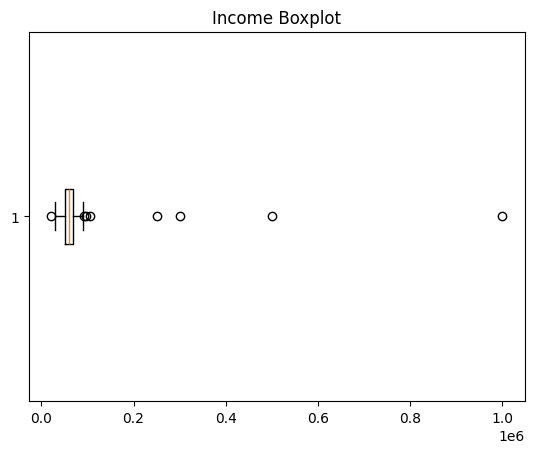

In [3]:
import matplotlib.pyplot as plt

plt.boxplot(df["income"], vert=False)
plt.title("Income Boxplot")
plt.show()

**Shows:**
- Median
- Spread (IQR)
- Extreme values

**Histogram**

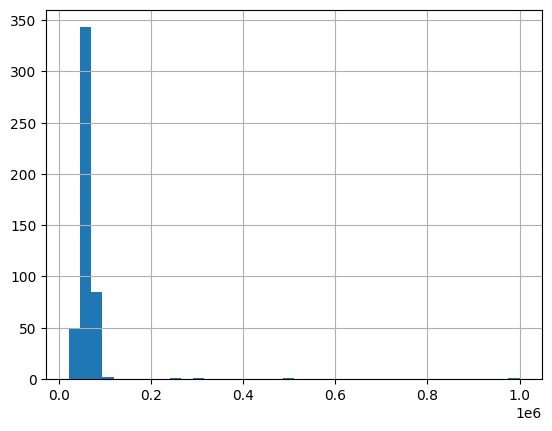

In [4]:
df["income"].hist(bins=40)
plt.show()

Long tail = outliers present

#### Statistical Detection (Structured)
**IQR Method**

In [5]:
Q1 = df["income"].quantile(0.25)
Q3 = df["income"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["income"] < lower) | (df["income"] > upper)]
len(outliers)

8

- Robust
- Distribution-agnostic
- Industry standard

**Z-Score Method**

In [6]:
from scipy.stats import zscore

df["z"] = zscore(df["income"])
df[df["z"].abs() > 3]

,income,age,z
480,250000.0,34,3.691463
481,300000.0,43,4.683458
482,500000.0,38,8.651440
483,1000000.0,45,18.571394


- Assumes normal distribution
- Bad for skewed data

### Outlier Treatment Strategies
#### Remove
```python
df_clean = df[(df["income"] >= lower) & (df["income"] <= upper)]
```

- Simple
- Information loss
- Dangerous for small datasets

#### Capping / Flooring 
```python
df["income_capped"] = df["income"].clip(lower, upper)
```

- Preserves rank
- Reduces impact
- Safe for regression

#### Log Transformation
```python
df["income_log"] = np.log1p(df["income"])
```

Shrinks extreme values naturally

#### Robust Scaling
```python
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df["income_scaled"] = scaler.fit_transform(df[["income"]])
```
- Uses median & IOQ
- Designed for outliers

### Algorithm-Specific Rules
| Algorithm           | Outlier Sensitivity |
| ------------------- | ------------------- |
| Linear Regression   | High             |
| Logistic Regression | High             |
| KNN                 | High             |
| SVM                 | High             |
| Decision Trees      | Low              |
| Random Forest       | Low              |
| XGBoost             | Low              |
